In [16]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score



In [17]:
df = pd.read_csv('Electric_Vehicle_Population_Data.csv')
df.head(30)

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,JN1AZ0CP5C,Stevens,Colville,WA,99114.0,2012,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73.0,7.0,153331706,POINT (-117.90454 48.54657),AVISTA CORP,5.306595e+10
1,JTMABABA7P,Yakima,Yakima,WA,98903.0,2023,SUBARU,SOLTERRA,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,15.0,253586308,POINT (-120.71847 46.55029),PACIFICORP,5.307700e+10
2,1N4AZ1CP1J,King,Seattle,WA,98122.0,2018,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,151.0,37.0,333135022,POINT (-122.31009 47.60803),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,5UX43EU09S,Kitsap,Poulsbo,WA,98370.0,2025,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,40.0,23.0,267525737,POINT (-122.64681 47.73689),PUGET SOUND ENERGY INC,5.303594e+10
4,3C3CFFGE5F,Thurston,Yelm,WA,98597.0,2015,FIAT,500,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,87.0,2.0,474468501,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,5.306701e+10
5,1N4AZ0CP1F,Thurston,Olympia,WA,98502.0,2015,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,84.0,22.0,226741833,POINT (-122.92333 47.03779),PUGET SOUND ENERGY INC,5.306701e+10
6,WBY1Z2C59F,Snohomish,Lynnwood,WA,98037.0,2015,BMW,I3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,81.0,32.0,208518453,POINT (-122.27734 47.83785),PUGET SOUND ENERGY INC,5.306105e+10
7,1C4RJXR6XR,Snohomish,Snohomish,WA,98290.0,2024,JEEP,WRANGLER,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,21.0,44.0,258162341,POINT (-122.09305 47.91265),PUGET SOUND ENERGY INC,5.306105e+10
8,5YJ3E1EC8P,Whitman,Palouse,WA,99161.0,2023,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,9.0,233627642,POINT (-117.0768 46.91008),AVISTA CORP,5.307500e+10
9,YV4BR0PKXJ,Kitsap,Kingston,WA,98346.0,2018,VOLVO,XC90,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,19.0,23.0,316199201,POINT (-122.4977 47.79802),PUGET SOUND ENERGY INC,5.303509e+10


## DATA CLEANING ##

The state column contained only one unique value and is droppped as it provides no additional analytical value.

In [18]:
if df['State'].nunique() == 1:
    df = df.drop(columns=['State'])

In [19]:
df.isnull().sum()

VIN (1-10)                                             0
County                                                24
City                                                  24
State                                                  0
Postal Code                                           24
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                        11
Legislative District                                 700
DOL Vehicle ID                                         0
Vehicle Location                                     109
Electric Utility                                      24
2020 Census Tract                                     24
dtype: int64

In [20]:
df.describe()

,Postal Code,Model Year,Electric Range,Legislative District,DOL Vehicle ID,2020 Census Tract
count,279756.000000,279780.000000,279769.000000,279080.000000,2.797800e+05,2.797560e+05
mean,98176.111447,2022.074072,39.172256,28.827841,2.462994e+08,5.297189e+10
std,2577.398040,3.059852,78.230356,14.908133,6.346205e+07,1.636194e+09
min,1030.000000,1999.000000,0.000000,1.000000,4.385000e+03,1.001020e+09
25%,98052.000000,2021.000000,0.000000,17.000000,2.213867e+08,5.303301e+10
50%,98133.000000,2023.000000,0.000000,32.000000,2.629453e+08,5.303303e+10
75%,98382.000000,2024.000000,32.000000,42.000000,2.790832e+08,5.305394e+10
max,99517.000000,2027.000000,337.000000,49.000000,4.791150e+08,6.601095e+10


In [26]:
#Standardize column names 

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[()\-]","", regex=True)

)

#--------------------------------------
#Fix data types
#--------------------------------------
df['postal_code'] = df['postal_code'].astype('str')
df['2020_census_tract'] = df['2020_census_tract'].astype('str')

#--------------------------------------
#handle missing values 
#--------------------------------------

#drop rows missing critical information for analysis
df = df.dropna(subset=['electric_range', 'city', 'county'])

#fill les critical ones 
df['legislative_distict'] = df['legislative_district'].fillna(df['legislative_district'].median())
df['electric_utility'] = df['electric_utility'].fillna('unknown')

#---------------------------------------
#drop dupllicates
#---------------------------------------

df.drop_duplicates(inplace=True)

#enforce uniqueness by VIN
df = df.drop_duplicates(subset=['vin_110'])

#clean categorical text
cat_cols =  ['make', 'model', 'city','electric_vehicle_type', 'county']
for col in cat_cols:
    df[col] = df[col].str.strip().str.title()

#Fix inconsistent values 
df['electric_vehicle_type'] = df['electric_vehicle_type'].replace({
    'Battery Electric Vehicle (BEV)': 'BEV',
    'Plug-in Hybrid Electric Vehicle (PHEV)': 'PHEV',
    'Fuel Cell Electric Vehicle (FCEV)': 'FCEV'
})

#outlier handling 
#remove unrealistic electric ranges
df = df[df['electric_range'] >=0]
df = df[df['electric_range']<=1000]

#Drop irrelevant columns

df = df.drop(columns=[
    'dol_vehicle_id',
    'vin-_110',
], errors='ignore')


## FEATURE ENGINEERING ##

In [27]:
# Age of the vehicle
df['vehicle_age'] = 2026 - df['model_year']

#Range category
df['range_category'] = pd.cut(
    df['electric_range'], 
    bins=[10, 100, 250, 400, 1000], 
    labels=['Low', 'Moderate', 'High', 'Very High']
)

#Final check
print(df.info())
print(df.describe())
print(df.isnull().sum())



<class 'pandas.core.frame.DataFrame'>
Int64Index: 17063 entries, 0 to 279630
Data columns (total 18 columns):
 #   Column                                           Non-Null Count  Dtype   
---  ------                                           --------------  -----   
 0   vin_110                                          17063 non-null  object  
 1   county                                           17063 non-null  object  
 2   city                                             17063 non-null  object  
 3   state                                            17063 non-null  object  
 4   postal_code                                      17063 non-null  object  
 5   model_year                                       17063 non-null  int64   
 6   make                                             17063 non-null  object  
 7   model                                            17063 non-null  object  
 8   electric_vehicle_type                            17063 non-null  object  
 9   clean_alternativ

In [28]:
#save cleaned data
df.to_csv('Cleaned_Electric_Vehicle_Population_Data.csv', index=False)

In [33]:
df.shape

(17063, 18)

## EXPLATORY DATA ANALYSIS ##


# Univariate Analysis #

### Electric Vehicle Types (BEV VS PHEV) ###

Which one dominates??

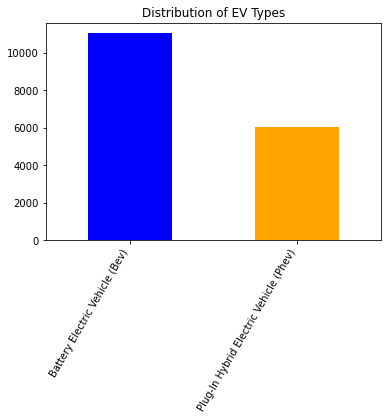

In [45]:
df['electric_vehicle_type'].value_counts().plot(kind='bar', color=['blue', 'orange'])
plt.title('Distribution of EV Types')
plt.xticks(rotation=60, ha='right')
plt.show()


## Adoption Trend ##

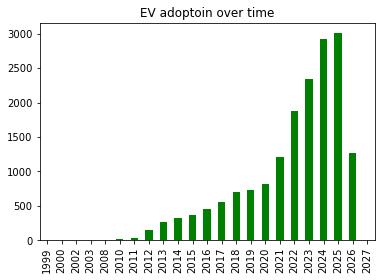

In [47]:
df['model_year'].value_counts().sort_index().plot(kind='bar', color='green')
plt.title('EV adoptoin over time')
plt.show()

### Distribution EVs BY Electric Range ###


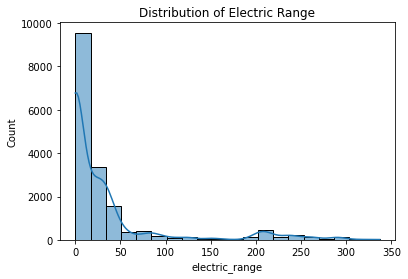

In [50]:
sns.histplot(df['electric_range'], bins=20, kde=True)
plt.title('Distribution of Electric Range')
plt.show()

### Top manufacturers ###

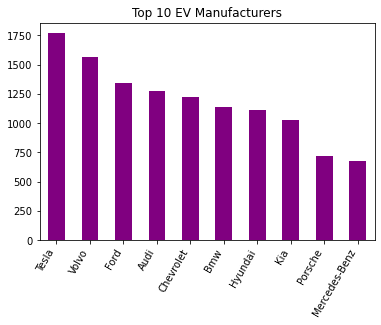

In [51]:
df['make'].value_counts().head(10).plot(kind='bar', color='purple')
plt.title('Top 10 EV Manufacturers')
plt.xticks(rotation=60, ha='right')
plt.show()

## Bivariate Analysis ##

### EV type VS Electric Range ###
BEVs usually have higher range than PHEVs

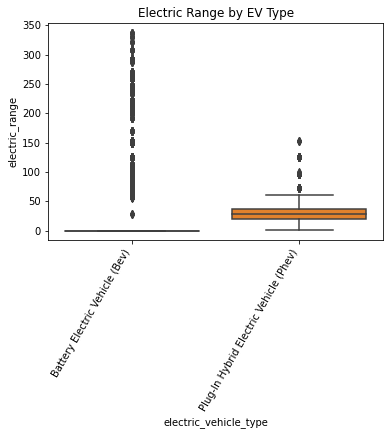

In [53]:
sns.boxplot(x='electric_vehicle_type', y='electric_range', data=df)
plt.title('Electric Range by EV Type')
plt.xticks(rotation=60, ha='right')
plt.show()

### Make vs Electric Range ###
Which brand offers better performance?

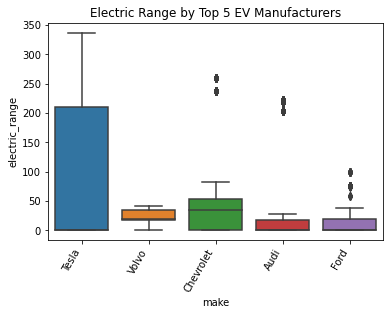

In [54]:
top_makes = df['make'].value_counts().head(5).index
sns.boxplot(
    data=df[df['make'].isin(top_makes)],
    x='make',
    y='electric_range'
)
plt.title('Electric Range by Top 5 EV Manufacturers')
plt.xticks(rotation=60, ha='right')
plt.show()



### Model Year vs Range ###
Technology improving over time?

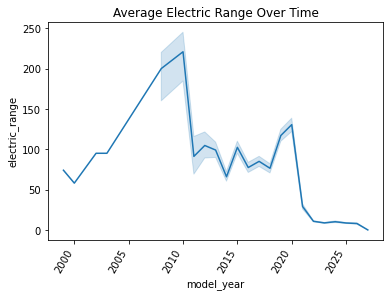

In [55]:
sns.lineplot(x='model_year', y='electric_range', data=df)
plt.title('Average Electric Range Over Time')
plt.xticks(rotation=60, ha='right')
plt.show()



## 